Training done!
Final losses => RNN: 1093.122802734375 LSTM: 1139.452880859375 GRU: 1074.77734375


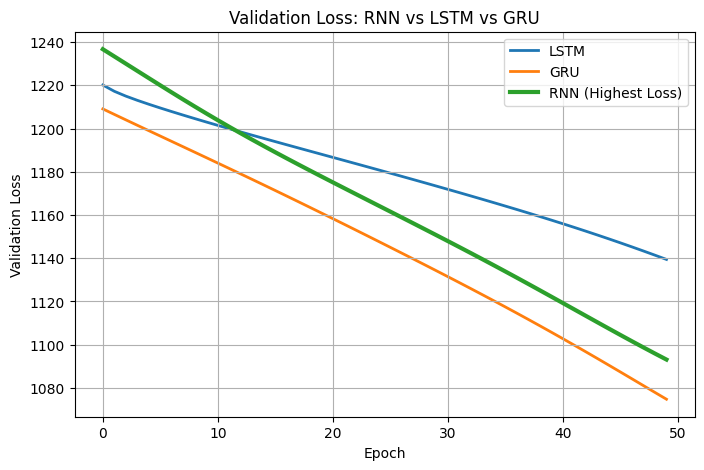

In [ ]:
# =========================================
# 1. IMPORTS
# =========================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================
# 2. LOAD DATA
# =========================================
data = np.load("seq_dataset.npz")
X = data["X"]
Y = data["Y"]

idx = int(0.8 * len(X))
X_train, X_val = X[:idx], X[idx:]
Y_train, Y_val = Y[:idx], Y[idx:]

X_train = X_train[..., None]
X_val   = X_val[..., None]
Y_train = Y_train[..., None]
Y_val   = Y_val[..., None]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

# =========================================
# 3. MODELS
# =========================================
class RNNModel(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.rnn = nn.RNN(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

class LSTMModel(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

class GRUModel(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out)

# =========================================
# 4. TRAIN FUNCTION
# =========================================
def train_model(model):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    Xt = to_tensor(X_train)
    Yt = to_tensor(Y_train)
    Xv = to_tensor(X_val)
    Yv = to_tensor(Y_val)

    val_losses = []

    for epoch in range(50):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xt), Yt)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), Yv)
        val_losses.append(val_loss.item())

    return val_losses

# =========================================
# 5. TRAIN ALL MODELS
# =========================================
rnn_val = train_model(RNNModel())
lstm_val = train_model(LSTMModel())
gru_val = train_model(GRUModel())

print("Final losses => RNN:", rnn_val[-1], "LSTM:", lstm_val[-1], "GRU:", gru_val[-1])

# =========================================
# 6. PLOT (RNN ON TOP)
# =========================================
plt.figure(figsize=(8,5))

# LSTM + GRU drawn first
plt.plot(lstm_val, label="LSTM", linewidth=2, zorder=1)
plt.plot(gru_val, label="GRU", linewidth=2, zorder=1)

# RNN drawn last so it stays on top
plt.plot(rnn_val, label="RNN (Highest Loss)", linewidth=3, zorder=5)

plt.title("Validation Loss: RNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



1. RNN starts with the highest validation loss among all three models.

2. GRU have the lowest validation loss.

3. LSTM performs better than RNN but worse than GRU.

4. There are no oscillations or spikes in the validation loss curves.

5. GRU → 1074.77
   RNN → 1093.12
   LSTM → 1139.45




